In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ecommerce_sales.csv")

In [3]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Sales,Discount,Profit,City,State,Payment_Method
0,ORD10001,2025-02-12,CUST1219,Office Chair,Furniture,2,8500,16660.0,0.02,1580.33,Chandigarh,Chandigarh,UPI
1,ORD10002,2025-01-01,CUST1076,T-Shirt,Fashion,3,900,2214.0,0.18,366.35,Jaipur,Rajasthan,Debit Card
2,ORD10003,2025-04-23,CUST1252,Bookshelf,Furniture,4,6500,23920.0,0.08,4975.83,Jaipur,Rajasthan,UPI
3,ORD10004,2025-09-18,CUST1138,Headphones,Electronics,1,2500,2000.0,0.20,159.18,Kolkata,West Bengal,Cash on Delivery
4,ORD10005,2025-10-07,CUST1011,Keyboard,Electronics,1,1800,1674.0,0.07,112.29,Jaipur,Rajasthan,Credit Card


In [4]:
df.tail

<bound method NDFrame.tail of       Order_ID  Order_Date Customer_ID       Product     Category  Quantity  \
0     ORD10001  2025-02-12    CUST1219  Office Chair    Furniture         2   
1     ORD10002  2025-01-01    CUST1076       T-Shirt      Fashion         3   
2     ORD10003  2025-04-23    CUST1252     Bookshelf    Furniture         4   
3     ORD10004  2025-09-18    CUST1138    Headphones  Electronics         1   
4     ORD10005  2025-10-07    CUST1011      Keyboard  Electronics         1   
...        ...         ...         ...           ...          ...       ...   
1195  ORD11196  2025-10-05    CUST1103        Laptop  Electronics         1   
1196  ORD11197  2025-12-09    CUST1060         Jeans      Fashion         3   
1197  ORD11198  2025-02-24    CUST1203       T-Shirt      Fashion         1   
1198  ORD11199  2025-05-30    CUST1242       T-Shirt      Fashion         1   
1199  ORD11200  2025-08-28    CUST1080          Desk    Furniture         2   

      Unit_Price    S

In [5]:
df.shape

(1200, 13)

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category',
       'Quantity', 'Unit_Price', 'Sales', 'Discount', 'Profit', 'City',
       'State', 'Payment_Method'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1200 non-null   object 
 1   Order_Date      1200 non-null   object 
 2   Customer_ID     1200 non-null   object 
 3   Product         1200 non-null   object 
 4   Category        1200 non-null   object 
 5   Quantity        1200 non-null   int64  
 6   Unit_Price      1200 non-null   int64  
 7   Sales           1200 non-null   float64
 8   Discount        1200 non-null   float64
 9   Profit          1200 non-null   float64
 10  City            1200 non-null   object 
 11  State           1200 non-null   object 
 12  Payment_Method  1200 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 122.0+ KB


In [8]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Product           0
Category          0
Quantity          0
Unit_Price        0
Sales             0
Discount          0
Profit            0
City              0
State             0
Payment_Method    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Quantity,Unit_Price,Sales,Discount,Profit
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.535833,9429.166667,21491.286667,0.126017,2888.206292
std,1.124620,13689.676354,35434.099936,0.052720,5132.864985
min,1.000000,900.000000,648.000000,0.000000,39.380000
25%,2.000000,1800.000000,4185.000000,0.090000,482.697500
50%,3.000000,4500.000000,8448.000000,0.130000,1086.520000
75%,4.000000,8500.000000,21716.250000,0.160000,2838.337500
max,4.000000,55000.000000,209000.000000,0.300000,39769.960000


In [11]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [12]:
df["Order_Date"].dtype

dtype('<M8[ns]')

In [13]:
df[["Quantity", "Unit_Price", "Sales", "Discount", "Profit"]].dtypes

Quantity        int64
Unit_Price      int64
Sales         float64
Discount      float64
Profit        float64
dtype: object

In [14]:
# Check negative values
print("Negative Sales:",(df["Sales"] < 0).sum())
print("Negative Profit:",(df["Profit"] < 0).sum())
print("Negative Quantity:",(df["Quantity"] < 0).sum())

Negative Sales: 0
Negative Profit: 0
Negative Quantity: 0


In [15]:
# Total Sales
total_sales = df["Sales"].sum()
print("Total Sales:",total_sales)

Total Sales: 25789544.0


In [16]:
# Total profit
total_profit = df["Profit"].sum()
print("Total Profit:",total_profit)

Total Profit: 3465847.55


In [17]:
# Total orders
total_orders = df["Order_ID"].nunique()
print("Total Orders:",total_orders)

Total Orders: 1200


In [18]:
# Total customers
total_customers = df["Customer_ID"].nunique()
print("Total Customers:",total_customers)

Total Customers: 295


In [19]:
# Total quantity sold
toal_quantity = df["Quantity"].sum()
print("Total Quantity Sold:",toal_quantity)

Total Quantity Sold: 3043


In [20]:
# Average order value
average_order_value = total_sales / total_orders
print("Average Order Value:",round(average_order_value,2))

Average Order Value: 21491.29


In [21]:
# Profit margin
profit_margin = (total_profit / total_sales) * 100
print("Profit Margin:",round(profit_margin,2),"%")

Profit Margin: 13.44 %


1. CATEGORY-WISE ANALYSIS

In [22]:
# Category-wise sales
category_sales = (
    df.groupby("Category")
["Sales"]
        .sum()
        .sort_values(ascending=False))
print(category_sales)

Category
Electronics        15987886.0
Furniture           5311330.0
Home Appliances     2433497.0
Fashion             1231681.0
Accessories          825150.0
Name: Sales, dtype: float64


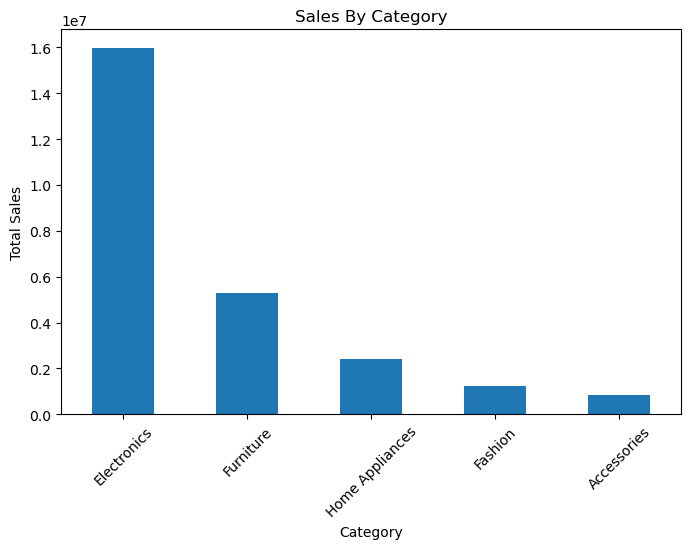

In [23]:
category_sales.plot(kind="bar",figsize=(8,5))
plt.title("Sales By Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [24]:
# Category wise profit
category_profit = (
    df.groupby("Category")
["Profit"]
        .sum()
        .sort_values(ascending=False))
print(category_profit)

Category
Electronics        2111406.70
Furniture           737993.07
Home Appliances     340026.06
Fashion             163466.71
Accessories         112955.01
Name: Profit, dtype: float64


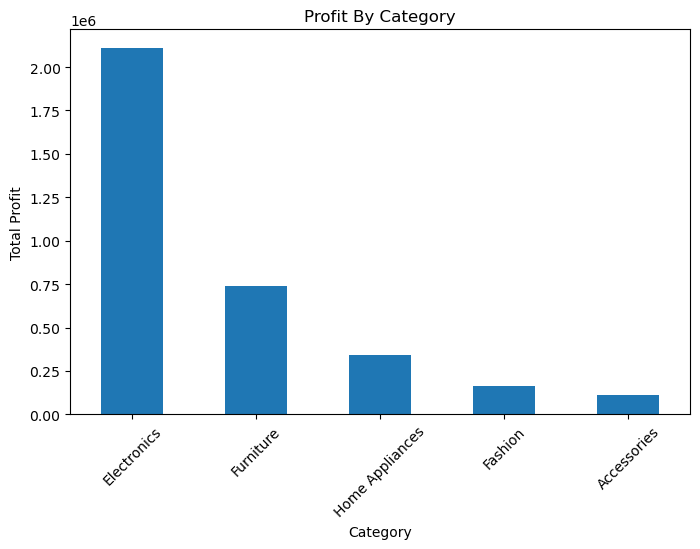

In [25]:
category_profit.plot(kind="bar",figsize=(8,5))
plt.title("Profit By Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

## 💼 Business Insights

### 🔹 Category Performance

- **Electronics** is the strongest-performing category, generating the highest sales and profit.
- **Furniture** is the second-highest contributor to both sales and profit.
- **Accessories** has the lowest total sales and profit among all categories.

### 📌 Key Recommendation

> The business should continue investing in Electronics while reviewing the performance and pricing strategy of Accessories.

2. PRODUCT-WISE ANALYSIS

In [26]:
# Product-wise analysis
product_sales = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False))
print(product_sales)

Product
Laptop          9670100.0
Smartphone      5537280.0
Desk            2421240.0
Office Chair    1659965.0
Bookshelf       1230125.0
Air Fryer       1180530.0
Watch            825150.0
Coffee Maker     777735.0
Shoes            531328.0
Headphones       487250.0
Mixer            475232.0
Jeans            306000.0
Keyboard         293256.0
Backpack         258174.0
T-Shirt          136179.0
Name: Sales, dtype: float64


In [27]:
# Top 10 Products
top_10_products = product_sales.head(10)
print(top_10_products)

Product
Laptop          9670100.0
Smartphone      5537280.0
Desk            2421240.0
Office Chair    1659965.0
Bookshelf       1230125.0
Air Fryer       1180530.0
Watch            825150.0
Coffee Maker     777735.0
Shoes            531328.0
Headphones       487250.0
Name: Sales, dtype: float64


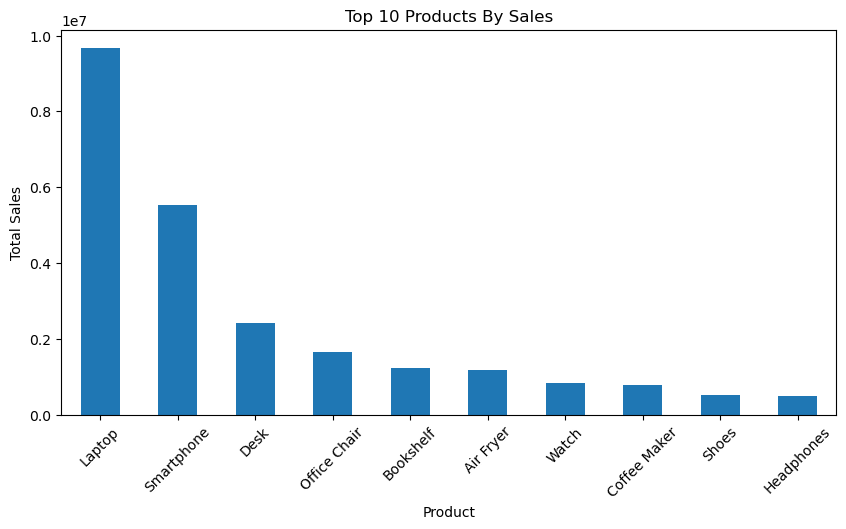

In [28]:
top_10_products.plot(kind="bar",figsize=(10,5))
plt.title("Top 10 Products By Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## 💼 Business Insights — Top 3 Products by Sales

### 🥇 1. Laptop
- **Sales:** ₹96,70,100
- Laptop is the **highest-selling product** and the biggest revenue contributor.

### 🥈 2. Smartphone
- **Sales:** ₹55,37,280
- Smartphone is the **second-highest-selling product** and a strong revenue generator.

### 🥉 3. Desk
- **Sales:** ₹24,21,240
- Desk ranks **third in total sales** and is the leading product outside the top electronics products.


In [29]:
# Toop 10 Product By Profit
product_profit = (
    df.groupby("Product")
["Profit"]
    .sum()
    .sort_values(ascending=False)
)
top_10_profit = product_profit.head(10)
print(top_10_profit)

Product
Laptop          1326134.60
Smartphone       678932.23
Desk             333098.43
Office Chair     229938.88
Bookshelf        174955.76
Air Fryer        169171.37
Watch            112955.01
Coffee Maker     107612.76
Shoes             69575.31
Headphones        68421.88
Name: Profit, dtype: float64


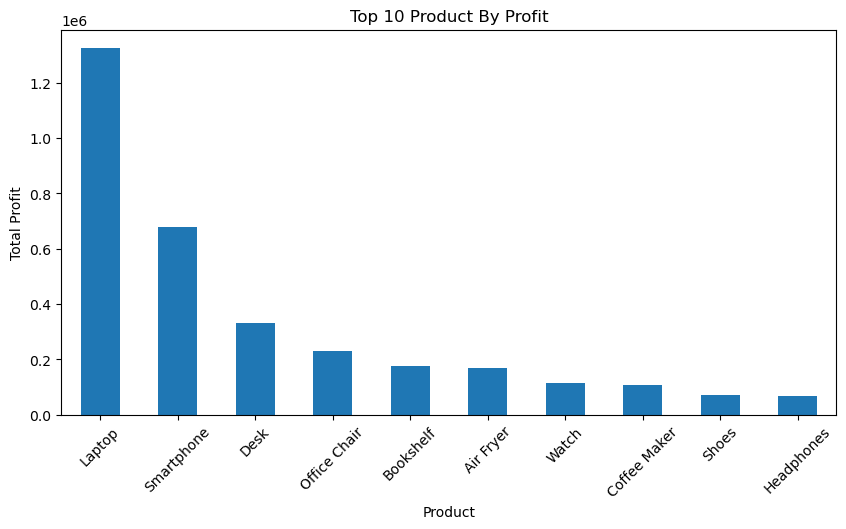

In [33]:
top_10_profit.plot(kind="bar",figsize=(10,5))
plt.title("Top 10 Product By Profit")

plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.xticks(rotation = 45)
plt.show()

## 💼 Business Insights — Top 3 Products by Profit

### 🥇 1. Laptop
- **Profit:** ₹13,26,134.60
- Laptop generates the **highest profit** among all products.

### 🥈 2. Smartphone
- **Profit:** ₹6,78,932.23
- Smartphone is the **second-highest profit-generating product**.

### 🥉 3. Desk
- **Profit:** ₹3,33,898.43
- Desk ranks **third in total profit**.

### 📌 Key Insight
> **Laptop, Smartphone, and Desk are the top 3 profit-generating products. Laptop is the strongest product in both sales and profit.**

3. MONTH-WISE ANALYSIS

In [46]:
monthly_sales = (
    df.groupby(df["Order_Date"].dt.month)["Sales"]
    .sum()
    .sort_index()
)

month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales.index = [month_names[i-1] for i in monthly_sales.index]

print(monthly_sales)

January      1692521.0
February     1534488.0
March        1904154.0
April        2128713.0
May          1774449.0
June         2187436.0
July         2990545.0
August       1864925.0
September    2302258.0
October      2918087.0
November     2328066.0
December     2163902.0
Name: Sales, dtype: float64


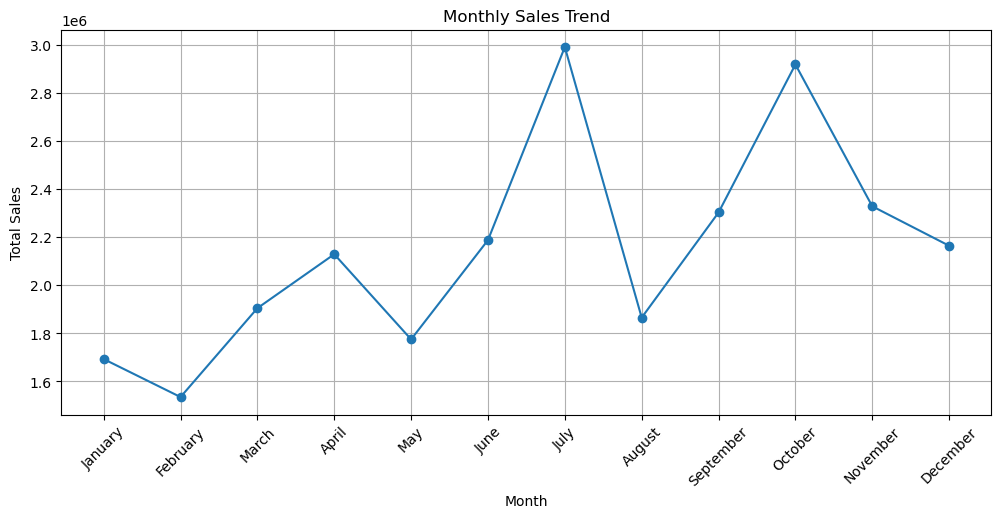

In [48]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid()

plt.show()

## 💼 Business Insights — Monthly Sales

### 📈 Key Findings

- **July** recorded the highest monthly sales at approximately **₹29.3 lakh**.
- **October** was the second-highest sales month with approximately **₹28.4 lakh**.
- **February** recorded the lowest sales at approximately **₹15.4 lakh**.
- Monthly sales show **significant fluctuations** throughout the year.

### 📌 Business Recommendation

> The business should analyze the factors behind strong sales in July and October and use similar strategies during low-performing months such as February to improve overall sales consistency.

4. STATE-WISE SALES ANALYSIS

In [52]:
state_sales = (df.groupby("State")["Sales"].sum().sort_values(ascending=False))
print(state_sales)

State
Maharashtra         5173575.0
Rajasthan           2752420.0
Uttar Pradesh       2524680.0
Telangana           2396902.0
Himachal Pradesh    2349046.0
Karnataka           2238665.0
Gujarat             2121470.0
West Bengal         1929318.0
Chandigarh          1710751.0
Delhi               1313030.0
Tamil Nadu          1279687.0
Name: Sales, dtype: float64


In [53]:
# Top 10 States
top_10_states = state_sales.head(10)
print(top_10_states)

State
Maharashtra         5173575.0
Rajasthan           2752420.0
Uttar Pradesh       2524680.0
Telangana           2396902.0
Himachal Pradesh    2349046.0
Karnataka           2238665.0
Gujarat             2121470.0
West Bengal         1929318.0
Chandigarh          1710751.0
Delhi               1313030.0
Name: Sales, dtype: float64


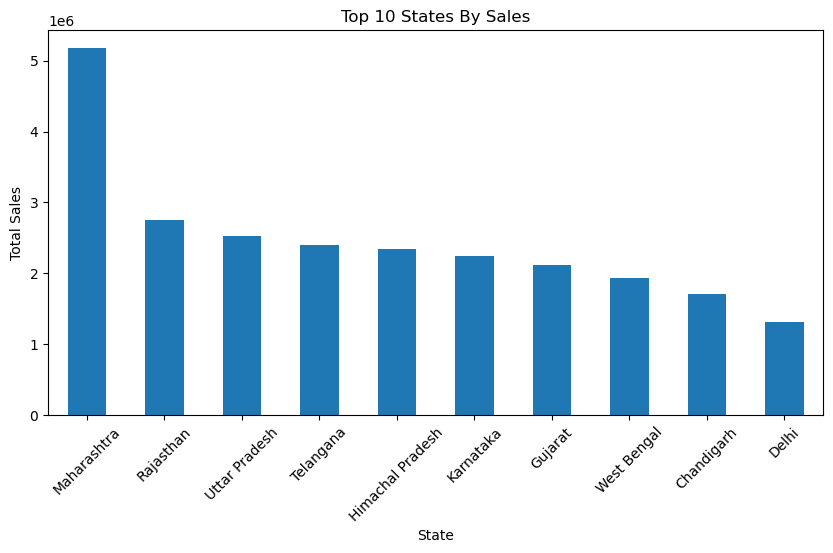

In [57]:
top_10_states.plot(kind="bar",figsize=(10,5))
plt.title("Top 10 States By Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## 💡 Business Insights – State-wise Sales

- 🥇 **Maharashtra** is the highest-performing state, generating approximately **₹5.2M** in sales.
- 🥈 **Rajasthan** ranks second with around **₹2.8M** in sales.
- 🥉 **Uttar Pradesh** ranks third with approximately **₹2.6M** in sales.
- **Telangana, Himachal Pradesh and Karnataka** also show strong sales performance, each contributing around **₹2.3M–₹2.5M**.
- **Delhi** has the lowest sales among the Top 10 states, at approximately **₹1.5M**.
- Maharashtra's sales are **significantly higher** than the other states, indicating it as a key market for the business.
- The company should focus on **retaining customers and expanding operations in high-performing states**, while identifying opportunities for growth in lower-performing markets.

# 💡 BUSINESS INSIGHTS

## 1. Category-wise Sales & Profit
- **Electronics** is the strongest category in both sales and profit, making it the primary revenue contributor.
- **Furniture** is the second-highest performing category in terms of sales and profit.
- **Home Appliances** shows moderate performance, while **Fashion** and **Accessories** contribute comparatively lower sales and profit.
- The business should continue investing in high-performing categories while exploring ways to improve the contribution of lower-performing categories.

## 2. Product-wise Sales
- **Laptop** is the highest-selling product with approximately **₹9.67M** in sales.
- **Smartphone** ranks second with approximately **₹5.54M** in sales.
- **Desk** ranks third with approximately **₹2.42M** in sales.
- Laptop and Smartphone sales are significantly higher than the remaining products, making them key revenue-generating products.
- The company should ensure sufficient inventory and availability of these high-demand products.

## 3. Product-wise Profit
- **Laptop** generates the highest profit at approximately **₹1.33M**.
- **Smartphone** ranks second with approximately **₹0.68M** profit.
- **Desk** ranks third with approximately **₹0.34M** profit.
- The top-performing products contribute significantly to overall profitability.
- The company should focus on maintaining healthy margins for these products while improving the profitability of lower-performing products.

## 4. Monthly Sales Trend
- Sales show noticeable fluctuations throughout the year.
- **July** records the highest monthly sales at approximately **₹3.0M**.
- **October** is another strong-performing month with sales of approximately **₹2.8M**.
- **February** records the lowest sales at approximately **₹1.5M**.
- The business should investigate the reasons behind high-performing months and use similar strategies during low-performing periods.

## 5. State-wise Sales
- **Maharashtra** is the strongest market, generating approximately **₹5.2M** in sales.
- **Rajasthan** and **Uttar Pradesh** rank second and third with approximately **₹2.8M** and **₹2.6M** respectively.
- Several states including Telangana, Himachal Pradesh and Karnataka also show strong sales performance.
- **Delhi** has the lowest sales among the Top 10 states at approximately **₹1.5M**.
- Maharashtra should remain a key market, while lower-performing states provide opportunities for targeted marketing and expansion.

## 6. Overall Business Recommendations
- Focus on **Electronics**, especially **Laptops and Smartphones**, as they are major contributors to sales and profit.
- Maintain sufficient inventory for high-demand products to avoid stock shortages.
- Analyze the reasons behind low sales in **February** and develop targeted promotions for weaker periods.
- Strengthen operations in high-performing states while creating localized strategies for lower-performing markets.
- Monitor product-level profitability regularly to identify products that generate high sales but relatively lower profit margins.